# <span style="color:black; font-weight:bold;">Cross-omics alignment Liver cancer Tutorial</span>
+ <span style="color:black; font-weight:bold;">Creator</span>: Bingjie Dai (17516970902@163.com)
+ <span style="color:black; font-weight:bold;">Date of Creation</span>: 6.23.2026
+ <span style="color:black; font-weight:bold;">Date of Last Modification</span>: 6.23.2026
+ <span style="color:black; font-weight:bold;">Download</span>: Cross-omics Liver cancer data used in the tutorial are available at [L_39.h5ad](https://drive.google.com/file/d/1NG9iqTtPPtLs60k4G1k-RQ0ebuPE0ZZb/view?usp=sharing) , [L39meta.h5ad](https://drive.google.com/file/d/1GXLOHqa-ov9tdytVAY40-A9zcMw9K783/view?usp=sharing). The raw data is from [PNAS](https://doi.org/10.1073/pnas.2505789122).
In this tutorial we apply MAPS to align 10xVisium to MALDI-MS Liver cancer dataset

<span style="color:black; font-weight:bold;">The dataset have:</span>   
+ <span style="color:black; font-weight:bold;">10xVisium(ST)</span>: 3914 spots and 18,085 genes   
+ <span style="color:black; font-weight:bold;">MALDI-MS(SM)</span>: 52,474 spots and 840 mz  

In [1]:
from MAPS.align import Rigid_alignment
from MAPS.utils import set_seed,rotate_and_translate_spatial
import scanpy as sc
import pandas as pd
import torch
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [3]:
set_seed(7)

## <span style="color:black; font-weight:bold;">Loading Cross-omics Liver cancer data</span>
+ To ensure the accuracy of the scaling factor, we recommend using the slice with a larger initial coordinate range as the target_adata for learning the scaling factor.

In [4]:
source_adata=sc.read_h5ad('/home/dbj/LPcross/Data/meta-RNA/L39meta.h5ad')
source_adata.obs['batch']='SM'

target_adata=sc.read_h5ad('/home/dbj/LPcross/Data/meta-RNA/RNA_liver0508/L_39.h5ad')
target_adata.obs['batch']='ST'
source_adata.var_names_make_unique()
target_adata.var_names_make_unique()

### Rotate and translate the  MALDI-MS(SM) Liver cancer

In [5]:
rotate_and_translate_spatial(source_adata,angle_deg=30,dx=15000,dy=2300)

## <span style="color:black; font-weight:bold;">Spatial mapping of the Liver cancer before alignment</span>

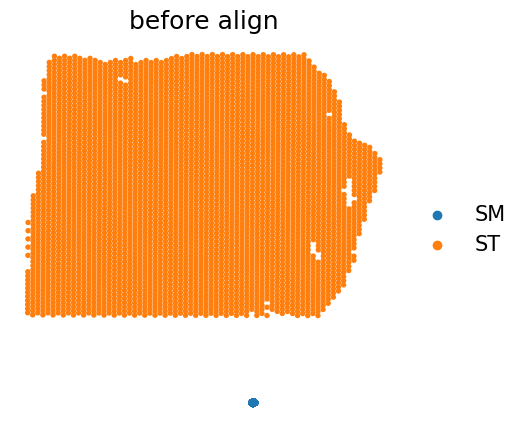

In [6]:
import matplotlib.pyplot as plt
import copy
plt.rcParams['figure.figsize'] = (5,5)
plt.rcParams['font.size'] = 15

adata=sc.concat([source_adata,target_adata],join='inner')
sc.pl.embedding(adata=adata, basis='spatial',color='batch',title='before align',size=60,frameon=False)

## <span style="color:black; font-weight:bold;">Align the slices using MAPS</span> 
### <span style="color:black; font-weight:bold;">Training parameters</span> 
+ epochs: Training ephchs  
+ device: Training device  
+ sample_size: The number of samples used for alignment  
+ enable_scale: Whether to learn the scaling factor?  

### <span style="color:black; font-weight:bold;">Output</span>   
+ aligned_spatial: The coordinates of the source slices after alignment  
+ theta_deg: Angle of rotation  
+ translation: Translation matrix  
+ scale: Scaling factor

In [7]:
%%time
source = source_adata.obsm['spatial'].astype(np.float32) 
target = target_adata.obsm['spatial'].astype(np.float32)  

aligned_spatial, theta_deg, translation,scale= Rigid_alignment(source, target, epochs=1000, sample_size=20000,enable_scale=True,device=device)
source_adata.obsm['spatial'] = aligned_spatial

Scanning angles to find best starting angle...


Global Align: 100%|███████████████████████████| 1000/1000 [00:04<00:00, 219.01it/s, Loss=132.18, Scale=92.779, Rot=-131.61°, Trans=(-3540.7, 19126.2)]


Peak GPU memory usage: 0.966 GB
Scale factor: 92.777, Rotation angle: -132.55°, Translation (x, y): (-3538.32, 19125.08)
CPU times: user 5.15 s, sys: 1.1 s, total: 6.25 s
Wall time: 6.77 s


## <span style="color:black; font-weight:bold;">Spatial mapping of the Liver cancer after alignment</span>

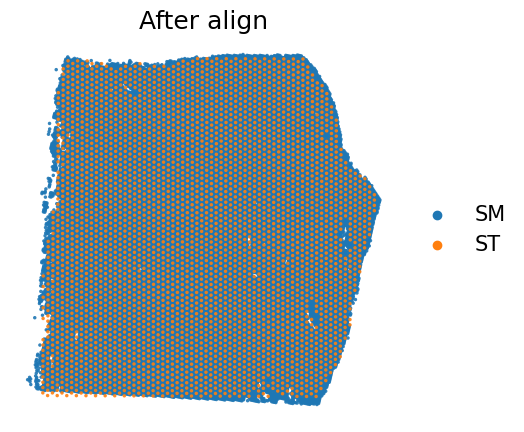

In [8]:
import matplotlib.pyplot as plt
import copy
plt.rcParams['figure.figsize'] = (5,5)
plt.rcParams['font.size'] = 15

adata=sc.concat([source_adata,target_adata],join='inner')
sc.pl.embedding(adata=adata, basis='spatial',color='batch',title='After align',alpha=0.9,size=25,frameon=False)

## <span style="color:black; font-weight:bold;">Spatial mapping of specific region markers in the metabolic and transcriptome</span>

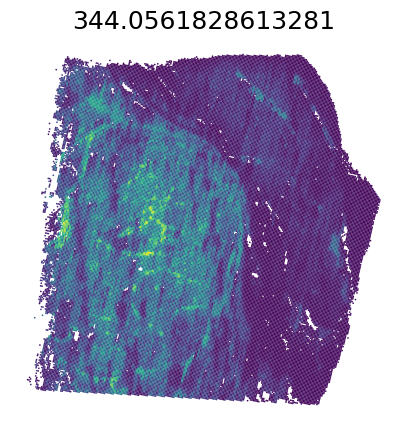

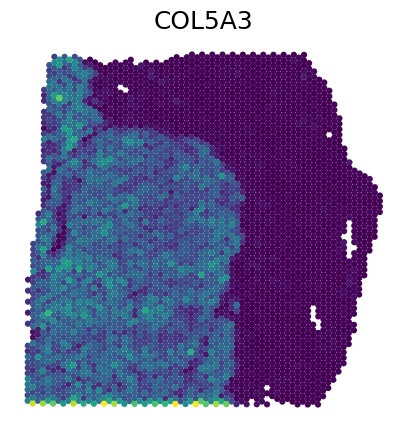

In [9]:
import matplotlib.pyplot as plt
import copy
plt.rcParams['figure.figsize'] = (5,5)
plt.rcParams['font.size'] = 15

sc.pl.embedding(source_adata,basis='spatial',color='344.0561828613281',size=6,frameon=False,colorbar_loc=None,legend_loc=None)
sc.pl.embedding(target_adata,basis='spatial',color='COL5A3',size=80,frameon=False,colorbar_loc=None,legend_loc=None)